In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import patches
import contextily as ctx
import netCDF4 as nc
import pandas as pd
from pathlib import Path

from iwave import Iwave

ROOT = Path.cwd()
sys.path.append(str(ROOT.parent))
from common.utils import median_filter_iwave

Definition of an IWaVE instance with video parameters

In [2]:
# video parameters
resolution = 0.04 # resolution in cm/pxl
fps = 30 # frame rate (frames per second)
vid_duration = 30 # whole video duration (seconds)
segment_duration = 5 # sub-segment duration (seconds)
win_size = (32,32) # size of a window (pxl)
filename = "ex1R_vid" # video ID
videopath = ROOT / "data" / "rectified_video" / f"{filename}_rectified.mp4" # video path
savepath = ROOT / "results" # results folder
savepath.mkdir(parents=True, exist_ok=True)

coordpath = ROOT / "data" / "GCPs" / "GCP_coordinates.xlsx" # GCP coordinates path

georef_coordpath = ROOT / "data" / "rectified_video" / f"{filename}_rectified.csv" # video coordinates path

In [3]:
iw = Iwave(
        resolution=resolution,
        window_size=win_size,  # size of interrogation windows over which velocities are estimated
        overlap=(-64,-64), # (win_size[0] / 2, win_size[1] / 2),  # overlap in space (y, x) used to select windows from images or frames
        time_size=int(segment_duration*fps),  # amount of frames in time used for one spectral analysis
        time_overlap=int(segment_duration*fps/2),  # amount of overlap in frames, used to establish time slices. Selecting half of
            # time_size implies that you use a 50% overlap in time between frame sets.
        fps=fps,
        smax = 1.5
    )

In [4]:
# read video
iw.read_video(videopath, start_frame=0, end_frame=int(vid_duration*fps)) #

100%|██████████| 900/900 [00:15<00:00, 58.41it/s]


In [5]:
print(iw)

# show the shape of the read images
print(f"Shape of the available images is {iw.imgs.shape}")

# show the shape of the manipulated windows
print(f"Shape of the windows set is {iw.windows.shape}")


Resolution [m]: 0.04
Window size (y, x): (32, 32)
Overlap (y, x): (-64, -64)
Size of time slices: 150
Overlap in time slices: 75
Number of images: 900
Frames per second: 30.0

Shape of the available images is (900, 860, 1900)
Shape of the windows set is (180, 900, 32, 32)


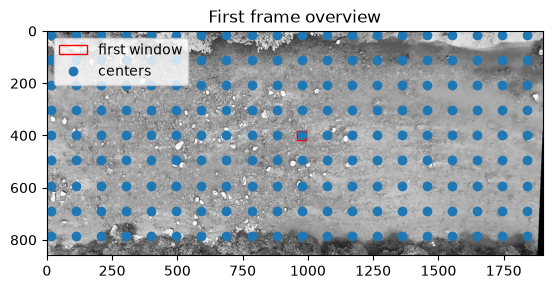

In [6]:
# plot image with measurement grid
ax = plt.axes()

# plot the first image with a patch at the first window and centers of rest in the first axes instance
win = np.int_(iw.windows.shape[0]/2)
xi, yi = np.meshgrid(iw.x, iw.y)
x_patch = np.int_(xi.flatten()[win]) - np.int_(win_size[0] / 2)
y_patch = np.int_(yi.flatten()[win]) - np.int_(win_size[1] / 2)
first_window = patches.Rectangle((x_patch, y_patch), win_size[0], win_size[1], linewidth=1, edgecolor='r', facecolor='none', label="first window")

ax.imshow(iw.imgs[0], cmap="Greys_r")
ax.add_patch(first_window)
ax.plot(xi.flatten(), yi.flatten(), "o", label="centers")
ax.legend()
ax.set_title("First frame overview")

plt.show()

VELOCITY CALCULATION

In [7]:
# calculate velocities
iw.velocimetry(
    alpha=0.85,  # alpha represents the depth-averaged velocity over surface velocity [-]
)

Optimization in 2 steps with spectrum downsampling factor [2, 1]


Optimizing windows: 100%|██████████| 180/180 [03:24<00:00,  1.14s/it]


RESULTS VISUALISATION

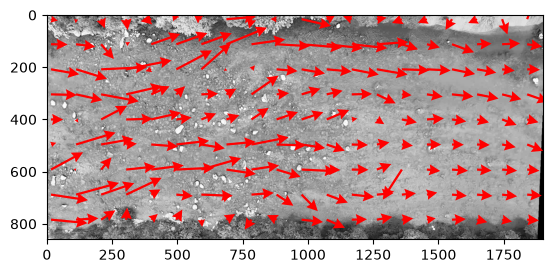

In [8]:
ax = plt.axes()
ax.imshow(iw.imgs[0], cmap="Greys_r")

# add velocity vectors
iw.plot_velocimetry(ax=ax, color="r", scale=10, headwidth=5, linewidth=5)  # you can add kwargs that belong to matplotlib.pyploy.quiver
plt.show()

EXTRACT RESULTS

In [9]:
ux, uy, d, q = iw.vx, iw.vy, iw.d, iw.quality
u = np.sqrt(ux**2 + uy**2)

GEOREFERENCE DATA

In [21]:
# load coordinates
print(georef_coordpath)
coord = pd.read_csv(georef_coordpath) # coordinates of each pixel in images

# associate coordinates
img_size_x = coord["x"].nunique()
img_size_y = coord["y"].nunique()

# reshape coordinates
x_mat = coord['x'].to_numpy().reshape(img_size_x,img_size_y)
y_mat = coord['y'].to_numpy().reshape(img_size_x,img_size_y)
xs_mat = coord['xs'].to_numpy().reshape(img_size_x,img_size_y)
ys_mat = coord['ys'].to_numpy().reshape(img_size_x,img_size_y)
lon_mat = coord['lon'].to_numpy().reshape(img_size_x,img_size_y)
lat_mat = coord['lat'].to_numpy().reshape(img_size_x,img_size_y)


# extract measurement points
# round indices
xi_int = xi.astype(int)
yi_int = yi.astype(int)

# xi_mg, yi_mg = np.meshgrid(xi_int, yi_int)

# extract coordinates
xm = x_mat[xi_int, yi_int]  
ym = y_mat[xi_int, yi_int]  
xs = xs_mat[xi_int, yi_int]  
ys = ys_mat[xi_int, yi_int]  
lon = lon_mat[xi_int, yi_int]  
lat = lat_mat[xi_int, yi_int]  

# project along Easting Northing
dx = xs[0,1] - xs[0,0]
dy = ys[1,0] - ys[0,0]

alpha = np.arctan2(dy, dx)  # radians CCW from x-axis

vE = ux * np.cos(alpha) + uy * np.sin(alpha)
vN = ux * np.sin(alpha) - uy * np.cos(alpha)

c:\Users\gdolc\_python\_iwave-training\iwave-training\example1_river\data\rectified_video\ex1R_vid_rectified.csv


VISUALISE RESULTS

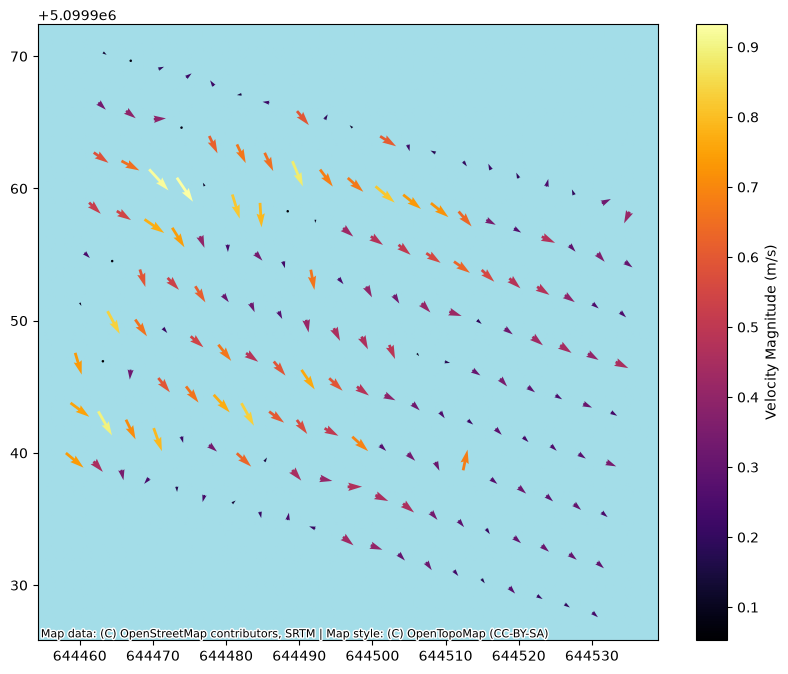

In [31]:

# georeferenced
fig, ax = plt.subplots(figsize=(10, 8))

qv = ax.quiver(xs, ys, vE, vN, u, scale=20, cmap="inferno")
             

plt.colorbar(qv, ax=ax, label="Velocity Magnitude (m/s)")
    
ctx.add_basemap(
    ax,
    # source=ctx.providers.Esri.WorldImagery,  # satellite
    source=ctx.providers.OpenTopoMap,  # satellite
    zoom=16
)
# ax.axis("equal")

FILTERING

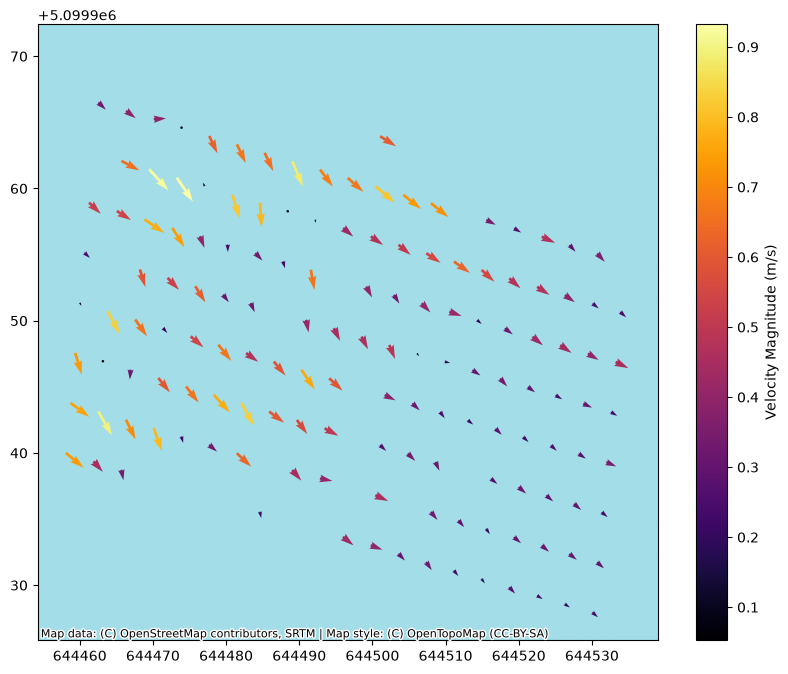

In [32]:
# median filtering

q_deviation = 0.03
q_threshold = 0.74

vE_masked, vN_masked = median_filter_iwave(vE, vN, q, dq = q_deviation, qth = q_threshold)

fig, ax = plt.subplots(figsize=(10, 8))

qv = ax.quiver(xs, ys, vE_masked, vN_masked, u, scale=20, cmap="inferno")
             

plt.colorbar(qv, ax=ax, label="Velocity Magnitude (m/s)")
    
ctx.add_basemap(
    ax,
    # source=ctx.providers.Esri.WorldImagery,  # satellite
    source=ctx.providers.OpenTopoMap,  # satellite
    zoom=16
)

SAVE RESULTS AS NC / csv

In [33]:
# Save results to netCDF file
with nc.Dataset(savepath / f"{filename}_results_georeferenced.nc", 'w', format='NETCDF4') as ds:
    ds.createDimension('x', xi.shape[1])
    ds.createDimension('y', xi.shape[0])

    # georeferencing coordinates
    xm_var = ds.createVariable('xm', 'f4', ('y', 'x'))
    ym_var = ds.createVariable('ym', 'f4', ('y', 'x'))
    xs_var = ds.createVariable('xs', 'f4', ('y', 'x'))
    ys_var = ds.createVariable('ys', 'f4', ('y', 'x'))
    lon_var = ds.createVariable('lon', 'f4', ('y', 'x'))
    lat_var = ds.createVariable('lat', 'f4', ('y', 'x'))

    xm_var[:, :] = xm
    ym_var[:, :] = ym
    xs_var[:, :] = xs
    ys_var[:, :] = ys
    lon_var[:, :] = lon
    lat_var[:, :] = lat
    
    vE_var = ds.createVariable('vE','f4', ('y', 'x'))
    vN_var = ds.createVariable('vN','f4', ('y', 'x'))
    q_var = ds.createVariable('q','f4', ('y', 'x'))
    
    vE_var[:, :] = vE_masked
    vN_var[:, :] = vN_masked
    q_var[:,:] = q